In [1]:
import sys
sys.path.append('..')
sys.path.append('../..')

In [2]:
import numpy as np
import pandas as pd
from os.path import join as pjoin
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import copy
from utils.misc import load_config

from tqdm import tqdm

/home/nasim/anaconda3/envs/ML/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
root = '../../data/filtered'

In [5]:
xPath = pjoin(root, 'X.h5')
yPath = pjoin(root, 'Y.h5')

In [6]:
X = pd.read_hdf(xPath)
Y = pd.read_hdf(yPath)

In [7]:
well_names = list(X.UWI.unique())

In [8]:
len(well_names)

1222

In [9]:
# removing all the wells that have less than 150 samples or patch_size
well_with_less_sample = [i for i in tqdm(well_names) if len(X[X.UWI == i]) < 150]

for well in well_with_less_sample:
    well_names.remove(well)

print(len(well_with_less_sample), len(well_names))

Y = Y[~X.UWI.isin(well_with_less_sample)]
X = X[~X.UWI.isin(well_with_less_sample)]

100%|██████████| 1222/1222 [00:30<00:00, 40.23it/s]


210 1012


In [10]:
key, val = np.unique(Y, return_counts=True)

In [11]:
data_config = load_config('../..', 'config/data', 'base.yaml')

In [12]:
lithology_classes = {
    'Undefined': 0,
    'Sand': 1,
    'ShalySand': 2,
    'SandyShale': 3,
    'Shale': 4,
    'Coal': 5,
    'CementedSand': 6
}

In [13]:
lithology_classes = {v: k for k, v in lithology_classes.items()}

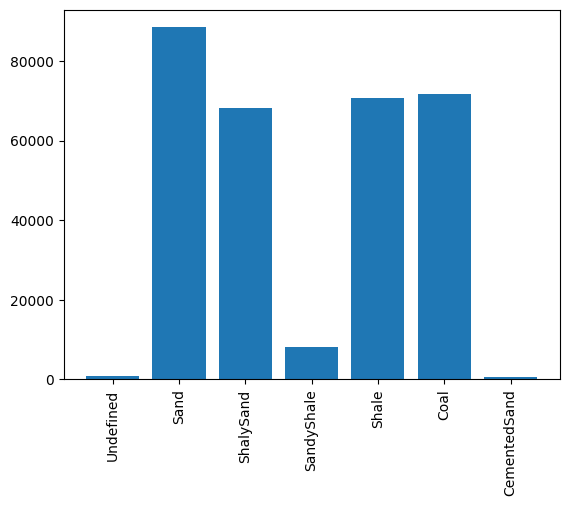

In [14]:
plt.bar([lithology_classes[k] for k in key], val)
plt.xticks(rotation=90)
plt.show()

In [15]:
X_orig = copy.deepcopy(X)
Y_orig = copy.deepcopy(Y)

In [16]:
well_names = X.UWI.unique()

In [17]:
lat_min, lat_max = X.lat.min(), X.lat.max()
lng_min, lng_max = X.lng.min(), X.lng.max()
depth_min, depth_max = X.DEPT.min(), X.DEPT.max()

In [18]:
X.lat = (X.lat - lat_min) / (lat_max - lat_min)
X.lng = (X.lng - lng_min) / (lng_max - lng_min)
X.DEPT = (X.DEPT - depth_min) / (depth_max - depth_min)

In [19]:
scaler = StandardScaler()
X.ILD = scaler.fit_transform(X.ILD.values.reshape(-1, 1))

scaler_gr = StandardScaler()
X.GR = scaler_gr.fit_transform(X.GR.values.reshape(-1, 1))

scaler_nphi = StandardScaler()
X.NPHI = scaler_nphi.fit_transform(X.NPHI.values.reshape(-1, 1))

scaler_dphi = StandardScaler()
X.DPHI = scaler_dphi.fit_transform(X.DPHI.values.reshape(-1, 1))

scaler_wtar = StandardScaler()
X.W_Tar = scaler_wtar.fit_transform(X.W_Tar.values.reshape(-1, 1))

scaler_sw = StandardScaler()
X.SW = scaler_sw.fit_transform(X.SW.values.reshape(-1, 1))

scaler_vsh = StandardScaler()
X.VSH = scaler_vsh.fit_transform(X.VSH.values.reshape(-1, 1))

scaler_phi = StandardScaler()
X.PHI = scaler_phi.fit_transform(X.PHI.values.reshape(-1, 1))

scaler_rw = StandardScaler()
X.RW = scaler_rw.fit_transform(X.RW.values.reshape(-1, 1))

In [20]:
X = X.drop(['UWI'], axis=1)

In [21]:
undefined_mask = Y == 0
Y_undefined = Y[undefined_mask]
X_undefined = X[undefined_mask]

Y = Y[~undefined_mask]
X = X[~undefined_mask]

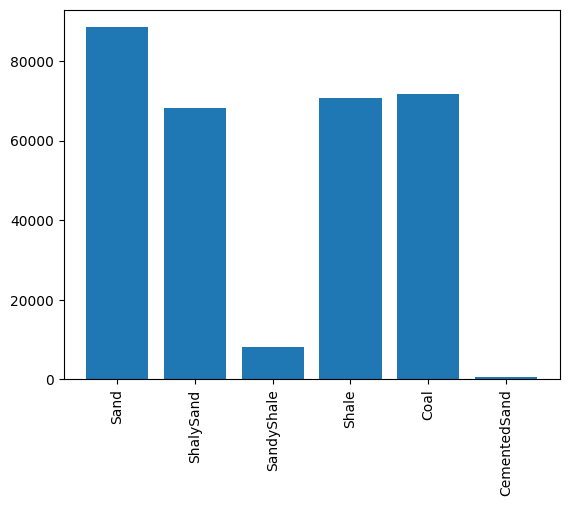

In [22]:
key, val = np.unique(Y, return_counts=True)

plt.bar([lithology_classes[k] for k in key], val)
plt.xticks(rotation=90)
plt.show()

In [23]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
X_test, X_val, Y_test, Y_val = train_test_split(X_val, Y_val, test_size=0.5, random_state=42)

In [24]:
classifier = RandomForestClassifier(
    n_estimators=50, 
    random_state=42, 
    n_jobs = -1, 
    verbose = 1, 
    criterion = 'log_loss',
)

classifier.fit(X_train, Y_train)
Y_train_pred = classifier.predict(X_train)
Y_val_pred = classifier.predict(X_val)
Y_test_pred = classifier.predict(X_test)

print('Accuracy Train: ', accuracy_score(Y_train, Y_train_pred))
print('Accuracy Val: ', accuracy_score(Y_val, Y_val_pred))
print('Accuracy Test: ', accuracy_score(Y_test, Y_test_pred))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  50 | elapsed:    1.9s remaining:   14.1s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    2.6s finished
[Parallel(n_jobs=48)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done   6 out of  50 | elapsed:    0.3s remaining:    2.5s
[Parallel(n_jobs=48)]: Done  50 out of  50 | elapsed:    0.5s finished
[Parallel(n_jobs=48)]: Using backend ThreadingBackend with 48 concurrent workers.


Accuracy Train:  0.9999959414101977
Accuracy Val:  0.9958764894964123
Accuracy Test:  0.9953569921101334


[Parallel(n_jobs=48)]: Done   6 out of  50 | elapsed:    0.0s remaining:    0.3s
[Parallel(n_jobs=48)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=48)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done   6 out of  50 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=48)]: Done  50 out of  50 | elapsed:    0.1s finished


In [25]:
Y_undefined_pred = classifier.predict(X_undefined)

Y_orig_to_be_replaced = copy.deepcopy(Y_orig)
Y_orig_to_be_replaced[Y_undefined.index] = Y_undefined_pred

[Parallel(n_jobs=48)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done   6 out of  50 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=48)]: Done  50 out of  50 | elapsed:    0.0s finished


In [26]:
well_with_undefined_class = [i for i in tqdm(X_orig.UWI.unique()) if 0 in Y_orig[X_orig.UWI == i].values]

100%|██████████| 1012/1012 [00:26<00:00, 38.55it/s]


In [27]:
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [28]:
labels = [lithology_classes[i] for i in lithology_classes]
class_color_dict = {0: '#200670', 1: '#084a03', 2: '#18fa07', 3: '#fa8107', 4: '#fa1c07', 5: '#0f0f0f', 6: '#02ebe3'}
class_color = [class_color_dict[i] for i in range(len(class_color_dict))]
cmap_facies_orig = colors.ListedColormap(class_color, 'indexed')
cmap_facies_pred = colors.ListedColormap(class_color[1:], 'indexed')

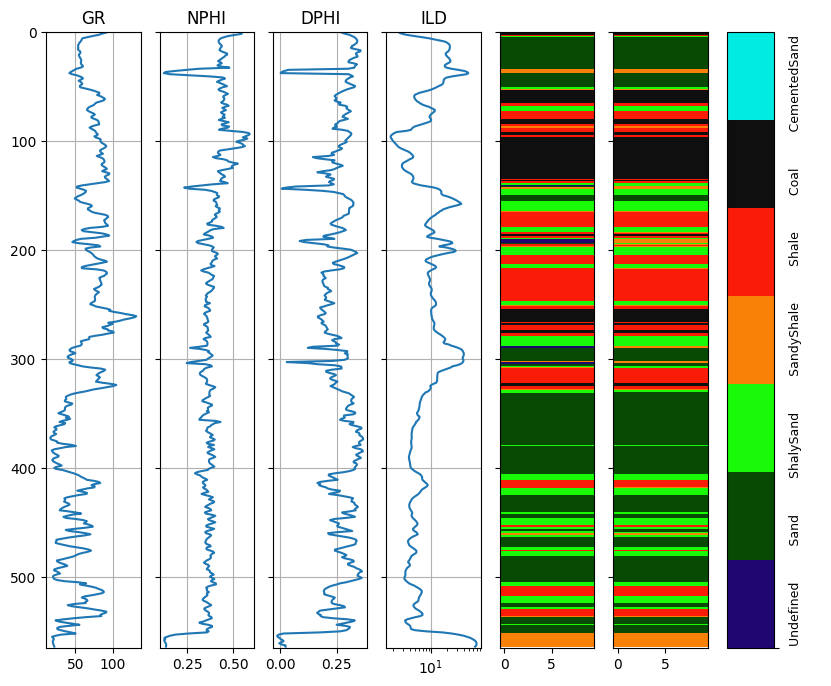

In [30]:
idx = np.random.randint(len(well_with_undefined_class))

well_data = X_orig[X_orig.UWI == well_with_undefined_class[idx]]
y_well_data = Y_orig[X_orig.UWI == well_with_undefined_class[idx]]
y_well_data_replaced = Y_orig_to_be_replaced[X_orig.UWI == well_with_undefined_class[idx]]
well_height = well_data.shape[0]

orignal_labels = np.repeat(y_well_data.values.reshape(-1, 1), 10, axis=1)
predicted_labels = np.repeat(y_well_data_replaced.values.reshape(-1, 1), 10, axis=1)

_, ax = plt.subplots(1, 7, figsize=(10, 8), sharey=True)
ax[0].plot(well_data.GR, list(range(0, well_height)), label='GR')
ax[1].plot(well_data.NPHI, list(range(0, well_height)), label='NPHI')
ax[2].plot(well_data.DPHI, list(range(0, well_height)), label='DPHI')
ax[3].plot(well_data.ILD, list(range(0, well_height)), label='ILD')

im = ax[4].imshow(orignal_labels, cmap=cmap_facies_orig, aspect='auto', vmin = 0, vmax = 6)
ax[5].imshow(predicted_labels, cmap=cmap_facies_pred, aspect='auto', vmin = 1, vmax = 6)

ax[3].set_xscale('log')
ax[0].set_ylim(0, well_height)
ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()

divider = make_axes_locatable(ax[-1])
cax = divider.append_axes("left", size="100%", pad=0)
cbar=plt.colorbar(im, cax=cax)
cbar.set_label((9*' ').join(labels), fontsize = 9, rotation=90)

ax[0].invert_yaxis()

ax[0].set_title('GR')
ax[1].set_title('NPHI')
ax[2].set_title('DPHI')
ax[3].set_title('ILD')

ax[-1].axis('off')

cbar.set_ticks(range(0,1)); cbar.set_ticklabels('')

<Axes: ylabel='Frequency'>

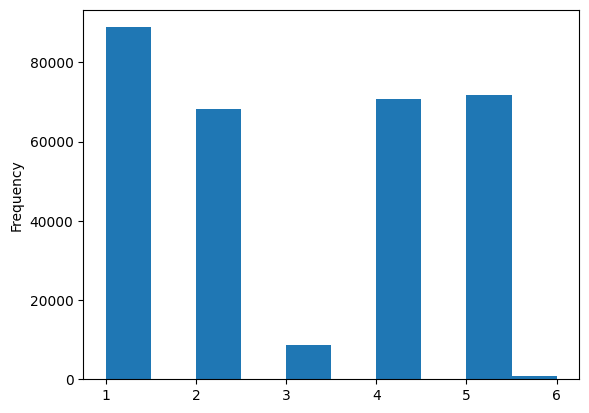

In [33]:
Y_orig_to_be_replaced.plot(kind='hist')

In [36]:
import os

In [37]:
Y_orig_to_be_replaced = Y_orig_to_be_replaced - 1
os.makedirs('../../data/noundefined', exist_ok=True)
X_orig.to_hdf('../../data/noundefined/X.h5', key='X', mode='w')
Y_orig_to_be_replaced.to_hdf('../../data/noundefined/Y.h5', key='Y', mode='w')

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [39]:
cm_test = confusion_matrix(Y_test, classifier.predict(X_test))
cm_test = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]

cm_train = confusion_matrix(Y_train, classifier.predict(X_train))
cm_train = cm_train.astype('float') / cm_train.sum(axis=1)[:, np.newaxis]

[Parallel(n_jobs=48)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done   6 out of  50 | elapsed:    0.1s remaining:    0.5s
[Parallel(n_jobs=48)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=48)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done   6 out of  50 | elapsed:    0.3s remaining:    2.2s
[Parallel(n_jobs=48)]: Done  50 out of  50 | elapsed:    0.4s finished
